# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Load Dataset
df = pd.read_csv('../diabetes_raw.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# melihat struktur kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# Statistik deskriptif
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


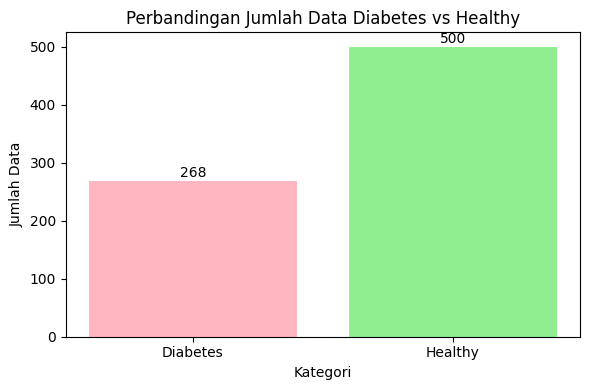

In [5]:
# Membuat pemisahan data
D = df[(df['Outcome'] != 0)]
H = df[(df['Outcome'] == 0)]

# Menghitung jumlah masing-masing
diabetes_count = len(D)
healthy_count = len(H)

# Plot
labels = ['Diabetes', 'Healthy']
counts = [diabetes_count, healthy_count]
colors = ['lightpink', 'lightgreen']  # warna beda

plt.figure(figsize=(6,4))
bars = plt.bar(labels, counts, color=colors)

# Menambahkan label jumlah pada masing-masing bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2,
             str(yval), ha='center', va='bottom', fontsize=10)

plt.xlabel('Kategori')
plt.ylabel('Jumlah Data')
plt.title('Perbandingan Jumlah Data Diabetes vs Healthy')
plt.tight_layout()
plt.show()


In [6]:
df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.nan)

In [7]:
# Mengecek missing value
print("\nJumlah Missing Value per Kolom:\n")
print(df.isnull().sum())


Jumlah Missing Value per Kolom:

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


C:\Users\zahra\AppData\Local\Temp\ipykernel_20288\481835628.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=missing_count.index, y=missing_count.values, palette='pastel')


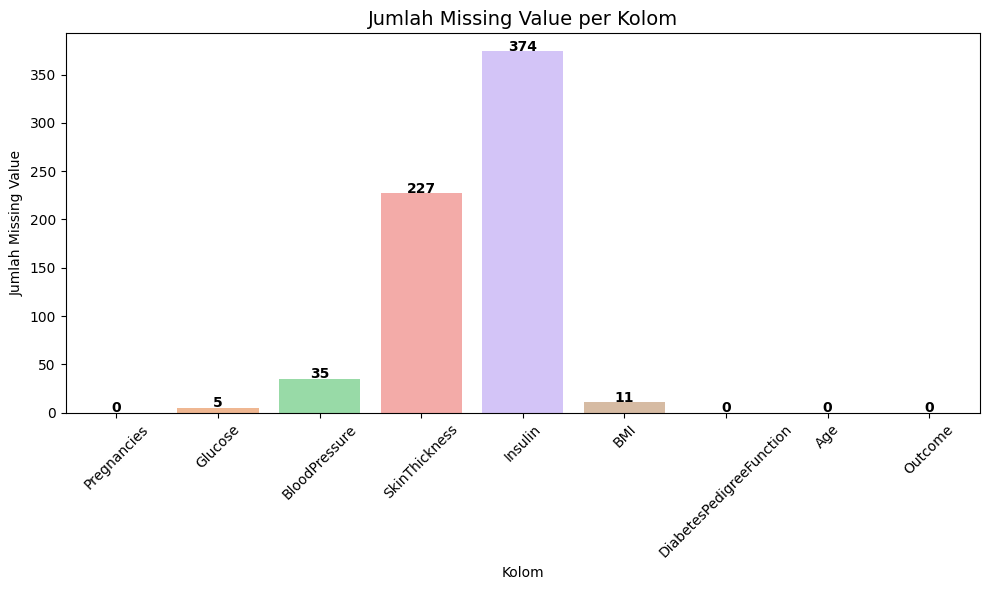

In [8]:
# Hitung missing value per kolom
missing_count = df.isnull().sum()

plt.figure(figsize=(10,6))
ax = sns.barplot(x=missing_count.index, y=missing_count.values, palette='pastel')

# Tambahkan label angka di atas bar
for i, value in enumerate(missing_count.values):
    ax.text(i, value + 0.5, str(value), ha='center', fontsize=10, fontweight='bold')

plt.title("Jumlah Missing Value per Kolom", fontsize=14)
plt.ylabel("Jumlah Missing Value")
plt.xlabel("Kolom")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# Mengecek jumlah baris yang duplikat
print("\nJumlah Duplikat:\n")
print(df.duplicated().sum())


Jumlah Duplikat:

0


<Figure size 1200x1000 with 0 Axes>

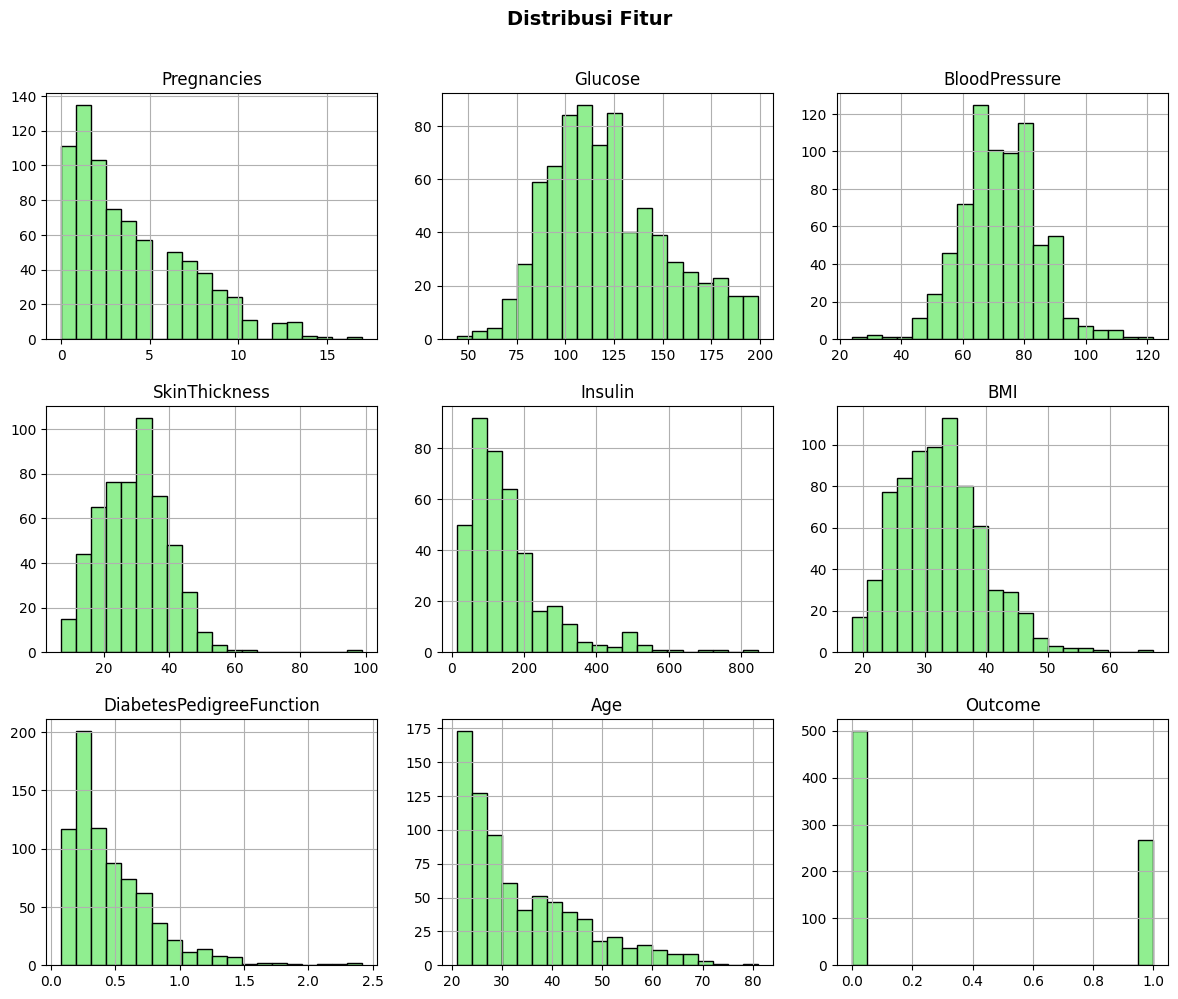

In [10]:
# Melihat distribusi masing-masing kolom numerik
plt.figure(figsize=(12,10))
df.hist(bins=20, figsize=(12,10), edgecolor='black', color='lightgreen') 

plt.suptitle("Distribusi Fitur", fontsize=14, fontweight='bold', y=1)
plt.tight_layout(pad=1.5)
plt.show()

In [11]:
# Memisahkan kolom numerik dan kategorikal
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

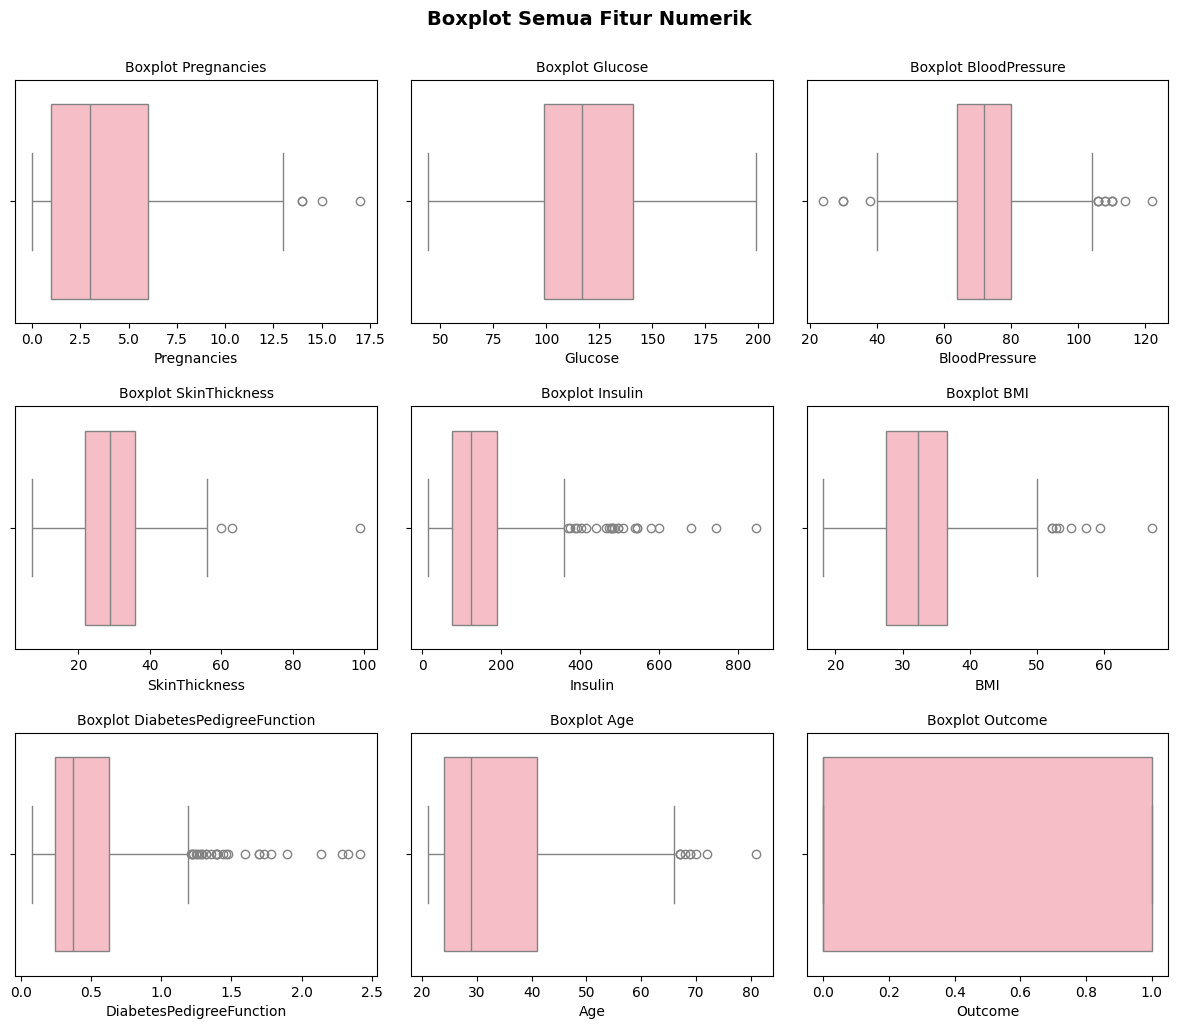

In [12]:
plt.figure(figsize=(12, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col], color='lightpink')
    plt.title(f'Boxplot {col}', fontsize=10)
    plt.tight_layout(pad=1.5)  # memberi jarak antar subplot

# Judul utama dibuat setelah loop dan sedikit digeser ke atas
plt.suptitle("Boxplot Semua Fitur Numerik", fontweight='bold',fontsize=14, y=1.03)

plt.show()

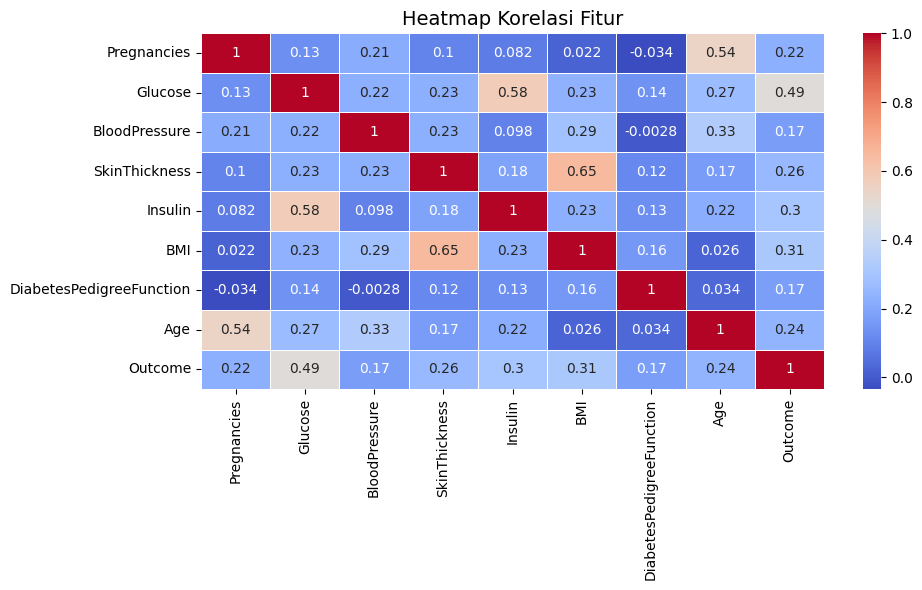

In [13]:
# Korelasi antar fitur
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap Korelasi Fitur", fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
df.shape

(768, 9)

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [15]:
# Membuat salinan DataFrame
df_clean = df.copy()

In [16]:
# Menangani data kosong (missing values) berdasarkan median tiap fitur
for col in ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']:
    df_clean[col].fillna(df_clean[col].median())

In [ ]:
# Normalisasi atau Standarisasi Fitur
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)